In [1]:
from lirads_model.dataset import LiRadsCaseDataset, collate_cases
from lirads_model.train import make_balanced_sampler
import torch

data_root = '/leonardo_scratch/fast/EUHPC_D35_139/nnunet_base/nnunet_format/amplifai/batch_001/cases'
train_csv = '/leonardo/home/userexternal/jcondess/LiRadsDetector/train_metadata.csv'
max_slices = 5
train_ds = LiRadsCaseDataset(train_csv, data_root, max_slices, augment=True, transplant=True)
loader = iter(torch.utils.data.DataLoader(
    train_ds,
    sampler=make_balanced_sampler(train_ds.df["lirads_score"]),
    batch_size=2,
    collate_fn=collate_cases))

/leonardo/prod/opt/libraries/cineca-ai/4.1.1/none/cineca-ai-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.Size([5, 224, 224])
torch.Size([5, 3, 224, 224])
tensor([0, 0]) tensor([1, 0])


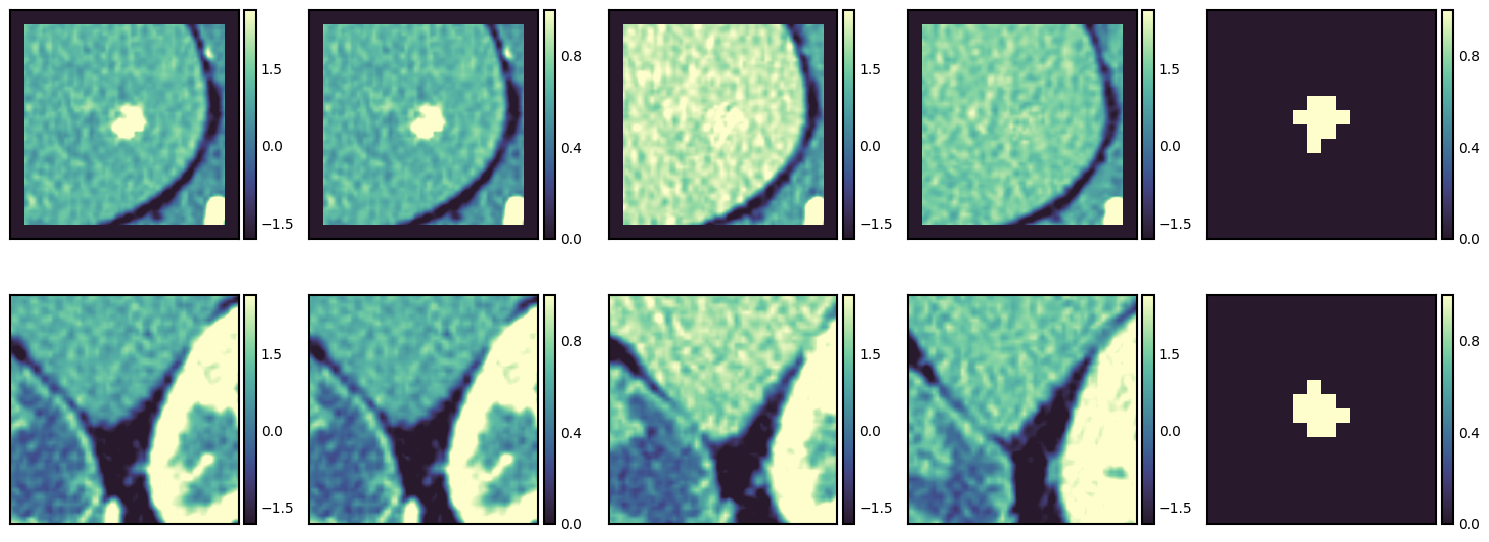

In [2]:
from matplotlib import pyplot as plt
from seaborn_image import ImageGrid

batch = next(loader)
print(batch['phase_data'][0]['ART'][-1].shape)
print(batch['phase_data'][0]['ART'][0].shape)
print(batch['cat_idx'], batch['ord_idx'])

ImageGrid([
    batch['phase_data'][0]['ART'][0][0,2,:,:],
    batch['phase_data'][0]['ART'][-1][0,:,:],
    batch['phase_data'][0]['VEN'][0][0,2,:,:],
    batch['phase_data'][0]['DEL'][0][0,2,:,:],
    #batch['phase_data'][0]['DRY'][0][0,2,:,:],
    batch['phase_data'][0]['VEN'][1][0,:,:],
    batch['phase_data'][1]['ART'][0][0,2,:,:],
    batch['phase_data'][1]['ART'][-1][0,:,:],
    batch['phase_data'][1]['VEN'][0][0,2,:,:],
    batch['phase_data'][1]['DEL'][0][0,2,:,:],
    #batch['phase_data'][1]['DRY'][0][0,2,:,:],
    batch['phase_data'][1]['VEN'][1][0,:,:]
    ], col_wrap = 5
)
